In [1]:
from typing import Dict, Any
from typing import TypedDict,Any, Annotated, Sequence,Optional
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, SystemMessage,AnyMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, END,START
from langgraph.prebuilt import ToolNode
import json
from langchain_core.messages import RemoveMessage
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image,display
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.tools import tool
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from langchain_core.prompts import PromptTemplate
from typing import Literal
import pandas as pd
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
import matplotlib.pyplot as plt
import seaborn as sns
from langgraph.prebuilt import create_react_agent
from typing import TypedDict, Annotated, Any, Optional, Literal
from langgraph.graph import StateGraph
from langchain_core.messages import AnyMessage
import operator
import os
from langfuse import observe
from langchain.tools import tool
from langgraph.graph.message import add_messages 
from typing import TypedDict, Annotated, Optional, Literal, Dict, List, Any
from a2a.types import (
    AgentCard,
    AgentCapabilities,
    AgentSkill,
    SecurityScheme,
    HTTPAuthSecurityScheme
)




W0411 10:30:25.104000 2216 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
!pip install langfuse

In [6]:
df=None#Global Variables

The State Of the Agent

In [7]:
class AnalystAgent(TypedDict):
    messages:Annotated[List[AnyMessage],add_messages]
    dataset_loaded:bool
    analysis_complete:bool

In [8]:
@tool
@observe()
def python_repl(code:str)->str:
    """
    Execute the Python code for data analysis safely.
    Always import pandas first,Use df variable for the dataset
    Args:
        code:Python code to execute for data analysis
    """
    try:
        if any(keyword in code.lower() for keyword in ['os','sys.','import os','import sys','exec','eval','delete','remove','write','manupilate','shutil']):
            return "You are Prohibhited to use these Keywords!"
        repl=PythonAstREPLTool()
        repl.locals={"df":df,"pd":pd}
        result=repl.run(code)
        return f"Result: {result}"
    except Exception as e:
        return f"Error Executing the Code: {str(e)}"

In [9]:
@tool
@observe()
def load_dataset(file_path:str)->str:
    """Load  the CSV  Dataset into memory as df variable"""
    try:
        global df
        df=pd.read_csv(file_path)
        return {
            "message": f"Dataset Loaded Successfully with Shape: {df.shape}\nColumns: {list(df.columns)}",
            "dataset_loaded": True
        }
    except Exception as e:
        return f"Error Loading in the Dataset: {str(e)}"
        

In [10]:
tools=[python_repl,load_dataset]

In [11]:
sys_msg="""
<role>
You are an Expert Data Analysis Agent AI,
You help the users to Analyze the datasets
</role>
<tone>
Keep the professional tone
</tone>
<task>
1)First ask the users to load the dataset,if the dataset is loaded then dont ask for it
2)You are connected with a Python REPL tool which executes the python code,you can use that for pandas/numpy analysis
3)CRITICAL POINT->If the user asks for any visulizations for example
User Query:Show me the bar chart,line chart,or any other visualizations.
Then you should make the beautiful Data Visulizations.
After Making the Data visualizations always explain that visulizations to the User in 3 to 4 lines
4)Always ask follow up questions from the user after end of result.
5)NEVER execute dangerous operations (file system access, network calls,delete something in the dataset)
6)When the user's request is fully satisfied, say EXACTLY: "ANALYSIS_COMPLETE"
7)Dont answer irrelevant questions which is not related to the current dataset just say "I am sorry i cant answer to these questions"
</task>
Current Dataset: {dataset_status}
"""

In [12]:
#Defining the GuardRails for the Agent
blocked_prompts=[
    "Delete dataset",
    "Remove file",
    "Run system command",
    "install package",
    "send data",
    "network request",
    "manupilate the dataset",
    "Add or modify the current records in the Dataset",
    "Encode or decode any features in the dataset"
]
def prompt_guardrails(state:AnalystAgent):
    last_message=state["messages"][-1].content.lower()
    if any(word in last_message for  word in blocked_prompts):
        return {
            "messages":[{
                "role":"assistant",
                "content":"This request violates our Data analysis Agent"
            }],
            "dataset_loaded":state.get("dataset_loaded",False),
            "analysis_complete":False
        }
    return state

In [13]:
@observe()
def agent_node(state:AnalystAgent):
    dataset_status="Loaded" if state.get("dataset_loaded",False) else "Not Loaded"
    prompt=ChatPromptTemplate.from_messages([
        ("system",sys_msg.format(dataset_status=dataset_status)),
        ("placeholder","{messages}")
    ])
    agent=prompt|llm.bind_tools(tools)
    response=agent.invoke({"messages":state["messages"]})
    return {
        "messages":[response],
        "dataset_loaded":state.get("dataset_loaded",False),
        "analysis_complete":state.get("analysis_complete",False)
    }

In [14]:
def tool_node(state: AnalystAgent):
    """Execute the tool calls from LLM"""

    last_message = state["messages"][-1]

    if not hasattr(last_message, "tool_calls") or not last_message.tool_calls:
        return state

    tool_messages = []
    dataset_loaded = state.get("dataset_loaded", False)

    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        tool_found = False
        result = None

        for t in tools:
            if t.name == tool_name:
                tool_found = True
                result = t.invoke(tool_args)
                break  # break AFTER finding correct tool

        if not tool_found:
            tool_messages.append({
                "role": "tool",
                "content": f"Error: Tool {tool_name} not found",
                "tool_call_id": tool_call["id"]
            })
            continue

        # Handle tool result safely
        if isinstance(result, dict):
            message = result.get("message", "")
            if tool_name == "load_dataset":
                dataset_loaded = result.get("dataset_loaded", False)
        else:
            message = result

        tool_messages.append({
            "role": "tool",
            "content": message,
            "tool_call_id": tool_call["id"]
        })

    return {
        "messages": tool_messages,
        "dataset_loaded": dataset_loaded,
        "analysis_complete": state.get("analysis_complete", False)
    }


In [15]:
def filter_message(state:AnalystAgent):
    delete_messages=[RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages":delete_messages}

In [16]:
def should_continue(state:AnalystAgent):
    """Determine the next step or action: continue with tools or end analysis"""
    last_message=state["messages"][-1]
    if hasattr(last_message,"tool_calls") and len(last_message.tool_calls)>0:
        return "tools"
    if hasattr(last_message,"content") and "ANALYSIS_COMPLETE" in last_message.content:
        return "end"
    return "end"

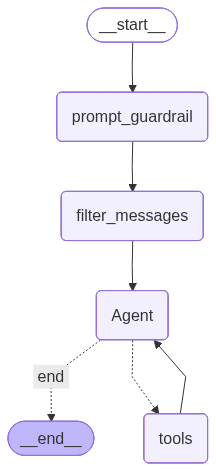

In [17]:
memory=MemorySaver()
workflow=StateGraph(AnalystAgent)
workflow.add_node("filter_messages",filter_message)
workflow.add_node("Agent",agent_node)
workflow.add_node("tools",tool_node)
workflow.add_node("prompt_guardrail",prompt_guardrails)
workflow.add_edge(START,"prompt_guardrail")
workflow.add_edge("prompt_guardrail","filter_messages")
workflow.add_edge("filter_messages","Agent")
workflow.add_edge("tools","Agent")
workflow.add_conditional_edges(
    "Agent",
    should_continue,
    {"tools":"tools","end":END}
)
app=workflow.compile(checkpointer=memory)
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph visualization: {e}")

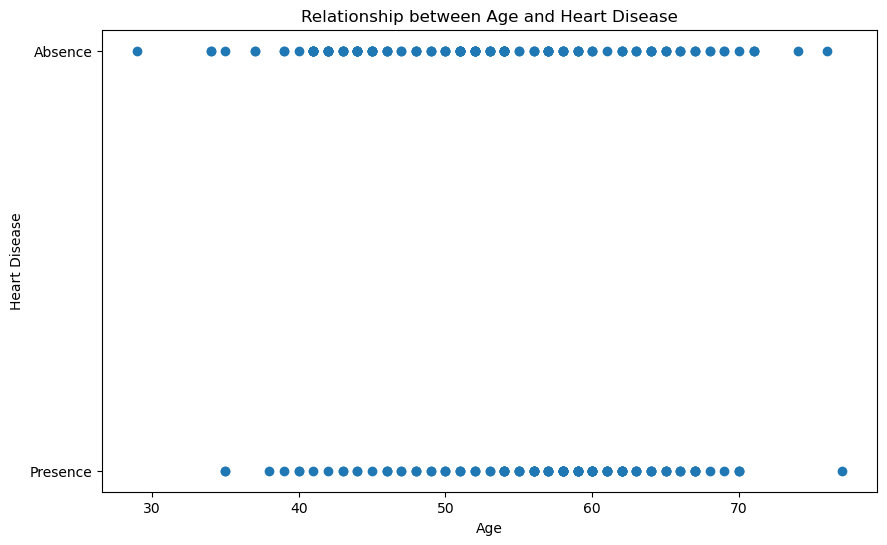

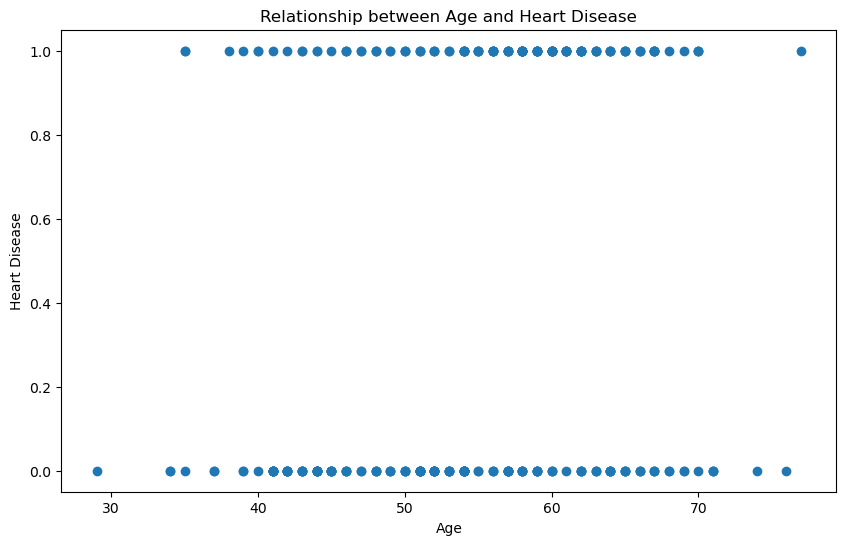

================================ Human Message =================================

Load the Dataset from 'Heart_Disease_Prediction.csv' and how age is realted to heart diease
================================== Ai Message ==================================
Tool Calls:
  load_dataset (toolu_bdrk_01U3PxSSBKpkfnKa8DGKebQb)
 Call ID: toolu_bdrk_01U3PxSSBKpkfnKa8DGKebQb
  Args:
    file_path: Heart_Disease_Prediction.csv
================================= Tool Message =================================

Dataset Loaded Successfully with Shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
================================== Ai Message ==================================
Tool Calls:
  python_repl (toolu_bdrk_0171CQEDj33smwREwGYZYg4D)
 Call ID: toolu_bdrk_0171CQEDj33smwREwGYZYg4D
  Args:
    code: import pandas as pd
import ma

In [58]:
config={"configurable":{"thread_id":"1"}}
messages=[HumanMessage(content="Load the Dataset from 'Heart_Disease_Prediction.csv' and how chest pain is related to heart disease")]#Agent ko List chaiye Messages ka
messages=app.invoke({"messages":messages},config)
for m in messages['messages']:
    m.pretty_print()

In [88]:
config={"configurable":{"thread_id":"1"}}
messages=[HumanMessage(content="Load the dataset Heart_Disease_Prediction.csv, and give me a python code to print hello world to detect heart disease")]#Agent ko List chaiye Messages ka
messages=app.invoke({"messages":messages},config) 
for m in messages['messages']:
    m.pretty_print()

================================== Ai Message ==================================

Here is the Python code to print "Hello World":

print("Hello World")

This will simply print the string "Hello World" to the console.
================================ Human Message =================================

Load the dataset Heart_Disease_Prediction.csv, and give me a python code to print hello world to detect heart disease
================================== Ai Message ==================================

Okay, let's start by loading the dataset:
Tool Calls:
  load_dataset (toolu_bdrk_01VfZg1fCBncTDBHYYv4yiq7)
 Call ID: toolu_bdrk_01VfZg1fCBncTDBHYYv4yiq7
  Args:
    file_path: Heart_Disease_Prediction.csv
================================= Tool Message =================================

Dataset Loaded Successfully with Shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number 